In [8]:
import subprocess
print(subprocess.run(['find', '/', '-iname', 'rawdata01.mat'], capture_output=True, text=True, timeout=30).stdout)

/home/jovyan/work/__shared/exam_projects/spike_threshold/rawdata01.mat



In [9]:
from scipy.io import loadmat #convert MATLAB.mat to Python，loadmat is a function, while scipy is an open source tool

mat = loadmat('/home/jovyan/work/__shared/exam_projects/spike_threshold/rawdata01.mat') #trace back to the file 
d = mat['d'] #structure d and si in python way  -> d corresponds to channel and time (electrophysiology recordings)/ si -> sampling interval in microsecondssi = mat['si'].item()

d.shape, si # output = 1,010,101 samples × 2 channels, and a 99 (µs) sampling interval 

((1010101, 2), 99)

In [14]:
import numpy as np
import matplotlib.pyplot as plt

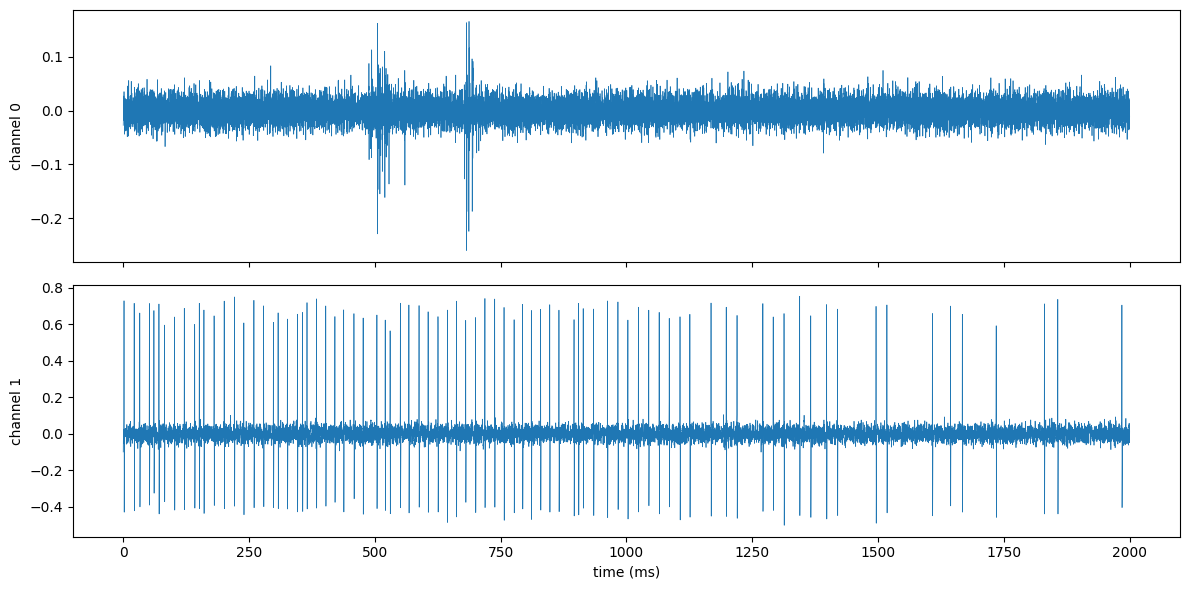

In [15]:
si_ms = si / 1000  # convert microseconds to milliseconds
t = np.arange(d.shape[0]) * si_ms  # time in ms for every sample

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
mask = t < 2000  # just look at the first 2 seconds for now

for ch in range(2):
    axes[ch].plot(t[mask], d[mask, ch], lw=0.5)
    axes[ch].set_ylabel(f'channel {ch}')

axes[-1].set_xlabel('time (ms)')
plt.tight_layout()
plt.show()

In [16]:
def spike_detect(d, si, thresholds, si_unit='us'):
    d = np.asarray(d)
    n_samples, n_channels = d.shape
    thresholds = np.atleast_1d(np.asarray(thresholds, dtype=float))
    si_ms = si / 1000.0 if si_unit == 'us' else si

    tsl = {}
    for ch in range(n_channels):
        x = d[:, ch]
        thr = thresholds[ch]

        if thr >= 0:
            above = x >= thr       # positive-going spike
        else:
            above = x <= thr       # negative-going spike

        # find the *first* sample of each crossing (rising edge of the mask)
        crossings = np.flatnonzero(above[1:] & ~above[:-1]) + 1
        tsl[ch] = crossings * si_ms

    return tsl

In [38]:
thresholds = [0.05, -0.15]  # positive for ch0, negative for ch1 — adjust based on your plot
tsl = spike_detect(d, si, thresholds, si_unit='us')

for ch, times in tsl.items():
    print(f"Channel {ch}: {len(times)} spikes detected")

Channel 0: 3748 spikes detected
Channel 1: 2369 spikes detected


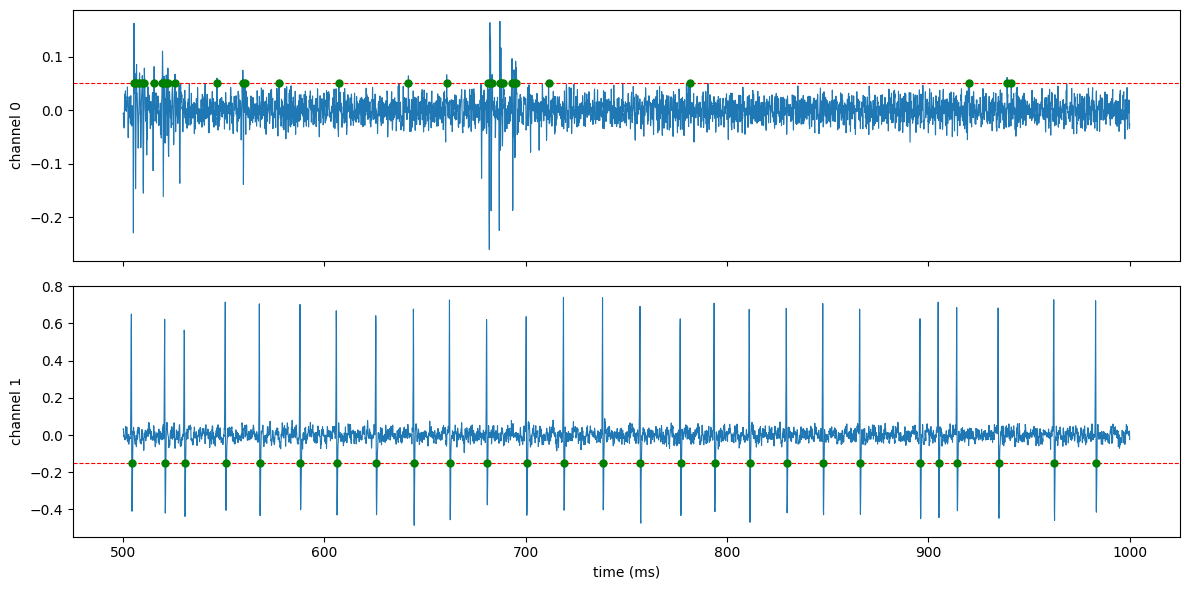

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
mask = (t > 500) & (t < 1000)  # zoom into a 500ms window

for ch in range(2):
    axes[ch].plot(t[mask], d[mask, ch], lw=0.8)
    axes[ch].axhline(thresholds[ch], color='r', ls='--', lw=0.8)  # show threshold line

    times = tsl[ch]
    times_in_range = times[(times > 500) & (times < 1000)]
    axes[ch].plot(times_in_range, [thresholds[ch]] * len(times_in_range), 'go', ms=5)

    axes[ch].set_ylabel(f'channel {ch}')

axes[-1].set_xlabel('time (ms)')
plt.tight_layout()
plt.show()

for ch, times in tsl.items():
    isi = np.diff(times)  # inter-spike intervals in ms
    print(f"Channel {ch}: min ISI = {isi.min():.3f} ms")